# Application 3 - E-Commerce Customer Behavior and Interest Discovery

Dataset: Womens Clothing E-Commerce Reviews.


## 1 Problem Description

Mục tiêu là phân tích hành vi khách hàng từ các review sản phẩm thời trang và phát hiện các đặc điểm liên quan đến mức độ hài lòng/khuyến nghị.

### Supervised-learning task được chọn

Chọn một target duy nhất là Recommended IND:

- X: các đặc trưng hành vi và ngữ cảnh review, ví dụ Age, Clothing ID, Division Name, Department Name, Class Name, độ dài review, sự hiện diện của title, Rating và Positive Feedback Count.
- y: Recommended IND, trong đó 1 là khách hàng khuyến nghị sản phẩm và 0 là không khuyến nghị.

Đây là bài toán phân loại nhị phân. Bài toán khác với hồi quy giá nhà vì đầu ra chỉ có hai nhãn 0 và 1, không phải một số liên tục.

In [2]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("Womens Clothing E-Commerce Reviews.csv")
TARGET_COLUMN = "Recommended IND"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2 Dataset

- Tên Kaggle: Womens Clothing E-Commerce Reviews.
- URL: https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews
- Đơn vị quan sát: một review sản phẩm, tương ứng một sự kiện thể hiện hành vi/ý kiến khách hàng.
- Target: Recommended IND.

Số review, số cột, mô tả feature và kiểu dữ liệu được xác nhận trực tiếp bằng các cell dưới đây.

In [3]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Số review/transactions: {df_raw.shape[0]:,}")
print(f"Số cột gốc: {df_raw.shape[1]}")
display(df_raw.head())

Số review/transactions: 23,486
Số cột gốc: 11


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


### Mô tả feature

- Clothing ID: mã sản phẩm.
- Age: tuổi khách hàng.
- Title và Review Text: tiêu đề/nội dung review.
- Rating: số sao từ 1 đến 5.
- Recommended IND: target, khách hàng có khuyến nghị hay không.
- Positive Feedback Count: số lượt đánh giá review là hữu ích.
- Division Name, Department Name, Class Name: cấp phân loại sản phẩm.

## 3 Data Inspection và 10.4 Data Cleaning

Kiểm tra cấu trúc, missing customer/review information, duplicate transaction, giá trị không hợp lệ, category không nhất quán và hành vi cực trị. Các kết quả quan sát dựa trên df_raw; dữ liệu dùng cho EDA được tạo riêng bên dưới, không ghi đè dữ liệu gốc.

In [4]:
df_raw.info()

quality_summary = pd.DataFrame({
    "Dtype": df_raw.dtypes.astype(str),
    "Missing count": df_raw.isna().sum(),
    "Missing (%)": (df_raw.isna().mean() * 100).round(2),
    "Unique values": df_raw.nunique()
}).sort_values("Missing count", ascending=False)
display(quality_summary)

print(f"Duplicate rows hoàn toàn: {df_raw.duplicated().sum():,}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


,Dtype,Missing count,Missing (%),Unique values
Title,object,3810,16.22,13993
Review Text,object,845,3.60,22634
Division Name,object,14,0.06,3
Department Name,object,14,0.06,6
Class Name,object,14,0.06,20
Unnamed: 0,int64,0,0.00,23486
Clothing ID,int64,0,0.00,1206
Age,int64,0,0.00,77
Rating,int64,0,0.00,5
Recommended IND,int64,0,0.00,2


Duplicate rows hoàn toàn: 0


Review Text thiếu 845 giá trị, tương đương 3.60%  
Ba cột phân loại sản phẩm gồm Division Name, Department Name và Class Name chỉ thiếu 14 giá trị, tương đương 0.06%, nên tỷ lệ thiếu rất nhỏ. Chúng có thể được xử lí ở bước sau bằng mode imputation hoặc gán nhãn riêng như Unknown.  
Các feature số quan trọng như Age, Rating, Recommended IND và Positive Feedback Count không có missing. Đặc biệt, target Recommended IND đầy đủ 23.486 giá trị, nên tất cả review đều có thể dùng cho bài toán phân loại sau này.  
Unnamed: 0 có 23.486 giá trị riêng biệt, bằng đúng số dòng dữ liệu, cho thấy đây chỉ là cột index cũ được lưu từ CSV. Cột này không mang ý nghĩa hành vi và cần loại bỏ

In [5]:
invalid_summary = pd.DataFrame({
    "Kiểm tra": [
        "Age <= 0",
        "Rating ngoài [1, 5]",
        "Recommended IND không thuộc {0, 1}",
        "Positive Feedback Count < 0"
    ],
    "Số bản ghi không hợp lệ": [
        int((df_raw["Age"] <= 0).sum()),
        int((~df_raw["Rating"].between(1, 5)).sum()),
        int((~df_raw[TARGET_COLUMN].isin([0, 1])).sum()),
        int((df_raw["Positive Feedback Count"] < 0).sum())
    ]
})
display(invalid_summary)

category_columns = ["Division Name", "Department Name", "Class Name"]
category_check = pd.DataFrame({
    "Unique trước strip": [df_raw[col].nunique(dropna=True) for col in category_columns],
    "Unique sau strip/lower": [
        df_raw[col].dropna().astype(str).str.strip().str.lower().nunique()
        for col in category_columns
    ]
}, index=category_columns)
display(category_check)

,Kiểm tra,Số bản ghi không hợp lệ
0,Age <= 0,0
1,"Rating ngoài [1, 5]",0
2,"Recommended IND không thuộc {0, 1}",0
3,Positive Feedback Count < 0,0


,Unique trước strip,Unique sau strip/lower
Division Name,3,3
Department Name,6,6
Class Name,20,20


Không phát hiện giá trị số không hợp lệ trong dataset: không có khách hàng có Age ≤ 0, không có Rating nằm ngoài thang điểm 1–5, target Recommended IND chỉ gồm hai nhãn hợp lệ 0 và 1, và Positive Feedback Count không có giá trị âm. Vì vậy, không cần loại bỏ bản ghi do các điều kiện không hợp lệ này.  
Với các biến phân loại Division Name, Department Name và Class Name, số lượng giá trị riêng biệt không thay đổi sau khi loại khoảng trắng thừa và chuyển về chữ thường. Điều này cho thấy không có dấu hiệu category bị ghi không nhất quán, ví dụ cùng một nhãn nhưng khác chữ hoa/thường hoặc thừa khoảng trắng.  
Do đó, dữ liệu nhìn chung có chất lượng tốt về miền giá trị và tính nhất quán của category

### Làm sạch phục vụ EDA

- Bỏ cột Unnamed: 0 vì đây là index được lưu trong CSV, không phải hành vi khách hàng.

In [6]:
df = df_raw.drop(columns="Unnamed: 0").copy()

## 4. Customer Representation

Mỗi dòng là một review. Khi train model sau này, Review Text được tokenizer/TF-IDF thành vector số; các category được one-hot encode; các cột số giữ dạng số hoặc scale. Recommended IND là target.

## 5. Interest Discovery - Target distribution

Trước khi mô hình hóa, cần quan sát tỷ lệ khách hàng khuyến nghị/không khuyến nghị. Nếu lệch lớp mạnh, bước modeling sau này không nên chỉ dùng Accuracy.

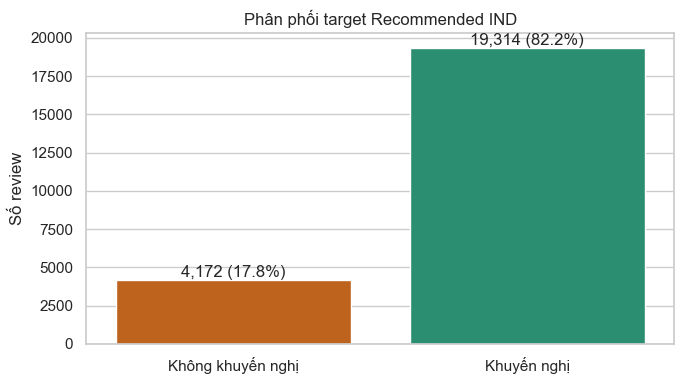

,Số review
Recommended IND,
0,4172
1,19314


In [8]:
target_counts = df[TARGET_COLUMN].value_counts().sort_index()
target_labels = target_counts.index.map({0: "Không khuyến nghị", 1: "Khuyến nghị"})

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=target_labels, y=target_counts.values, hue=target_labels, legend=False, palette=["#d95f02", "#1b9e77"])
for bar, count in zip(ax.patches, target_counts.values):
    ax.annotate(f"{count:,} ({count / len(df) * 100:.1f}%)",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom")
ax.set(title="Phân phối target Recommended IND", xlabel="", ylabel="Số review")
plt.tight_layout()
plt.show()
display(target_counts.to_frame("Số review"))

Target Recommended IND bị mất cân bằng mạnh, với lớp khuyến nghị chiếm 82.2% và lớp không khuyến nghị chỉ chiếm 17.8%. Vì vậy, Accuracy không đủ để đánh giá model trong giai đoạn sau. Cần báo cáo thêm Precision, Recall, F1-score và ROC-AUC; đặc biệt quan tâm Recall/F1-score của lớp 0 để đánh giá khả năng nhận diện các review không khuyến nghị. Khi huấn luyện có thể sử dụng stratify=y lúc chia train/test và thử class_weight="balanced" cho các model hỗ trợ tham số này.

### Phân phối đặc trưng số và hành vi cực trị

Age, Rating và Positive Feedback Count được quan sát để nhận ra nhóm tuổi, mức độ hài lòng và những review nhận tương tác cực cao. Positive Feedback Count thường lệch phải; outlier không tự động bị xóa vì có thể là review thật sự hữu ích.

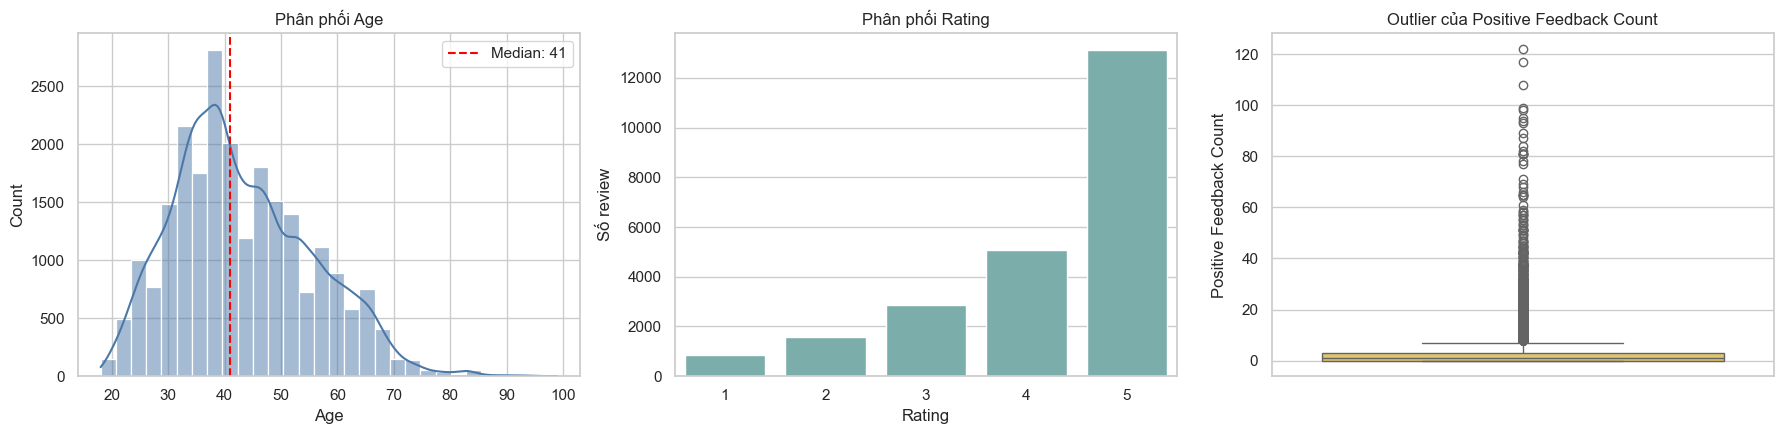

Ngưỡng outlier IQR của Positive Feedback Count: 7.50
Số review vượt ngưỡng: 2,147


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

sns.histplot(df["Age"], bins=30, kde=True, color="#4c78a8", ax=axes[0])
axes[0].axvline(df["Age"].median(), color="red", linestyle="--", label=f"Median: {df['Age'].median():.0f}")
axes[0].set_title("Phân phối Age")
axes[0].legend()

rating_counts = df["Rating"].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values, color="#72b7b2", ax=axes[1])
axes[1].set(title="Phân phối Rating", xlabel="Rating", ylabel="Số review")

sns.boxplot(y=df["Positive Feedback Count"], color="#f2cf5b", ax=axes[2])
axes[2].set_title("Outlier của Positive Feedback Count")
plt.tight_layout()
plt.show()

q1, q3 = df["Positive Feedback Count"].quantile([0.25, 0.75])
upper_bound = q3 + 1.5 * (q3 - q1)
print(f"Ngưỡng outlier IQR của Positive Feedback Count: {upper_bound:.2f}")
print(f"Số review vượt ngưỡng: {(df['Positive Feedback Count'] > upper_bound).sum():,}")

Tuổi khách hàng tập trung chủ yếu trong khoảng 30–55 tuổi, với median là 41 tuổi. Phân phối hơi lệch phải do có một số khách hàng lớn tuổi hơn, nhưng không có dấu hiệu giá trị tuổi bất thường.  
Rating tập trung mạnh ở mức 4 và đặc biệt là 5 sao. Điều này phù hợp với việc target Recommended IND có tỷ lệ khuyến nghị cao, vì khách hàng đánh giá cao thường có xu hướng khuyến nghị sản phẩm.  
Positive Feedback Count lệch phải mạnh. Phần lớn review nhận rất ít lượt đánh giá hữu ích, nhưng có một số review nhận số feedback rất lớn. 

### Danh mục sản phẩm và customer interests

Phân tích cấp Division, Department và Class để phát hiện ngành hàng/nhóm sản phẩm nhận nhiều review nhất. Đây là chỉ dấu về mức quan tâm trong phạm vi dữ liệu review.

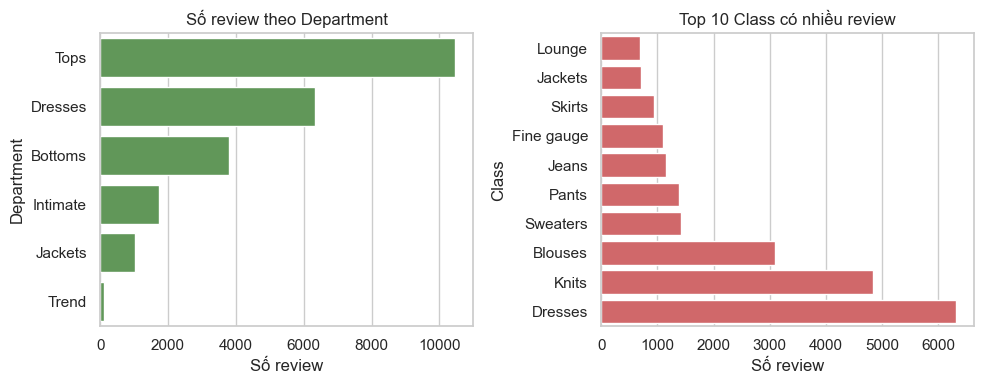

,Department review count,Department share (%)
Department Name,,
Tops,10468,44.60
Dresses,6319,26.92
Bottoms,3799,16.19
Intimate,1735,7.39
Jackets,1032,4.40
Trend,119,0.51


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

department_counts = df["Department Name"].value_counts()
sns.barplot(x=department_counts.values, y=department_counts.index, color="#59a14f", ax=axes[0])
axes[0].set(title="Số review theo Department", xlabel="Số review", ylabel="Department")

class_counts = df["Class Name"].value_counts().head(10).sort_values()
sns.barplot(x=class_counts.values, y=class_counts.index, color="#e15759", ax=axes[1])
axes[1].set(title="Top 10 Class có nhiều review", xlabel="Số review", ylabel="Class")
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "Department review count": department_counts,
    "Department share (%)": (department_counts / department_counts.sum() * 100).round(2)
}))

Ở cấp Department Name, review tập trung mạnh nhất ở Tops với 10.468 review (44.60%), tiếp theo là Dresses với 6.319 review (26.92%) và Bottoms với 3.799 review (16.19%). Như vậy, hai nhóm Tops và Dresses chiếm hơn 70% tổng số review trong dataset.  
Ở cấp chi tiết hơn là Class Name, ba loại sản phẩm có nhiều review nhất là Dresses, Knits và Blouses. Điều này cho thấy các review trong dữ liệu tập trung đáng kể vào nhóm váy và các loại áo.  
Trend có ít review nhất, chỉ 119 review (0.51%). Do số lượng mẫu thấp, các phân tích hành vi hoặc kết quả dự đoán cho nhóm này sau này có thể kém ổn định hơn các Department có nhiều review.

### Mối quan hệ giữa rating và hành vi khuyến nghị

Rating là biểu hiện trực tiếp của mức hài lòng. Cell này quan sát tỷ lệ Recommended IND theo số sao và theo Department, đồng thời kiểm tra sự mất cân bằng lớp theo nhóm sản phẩm.

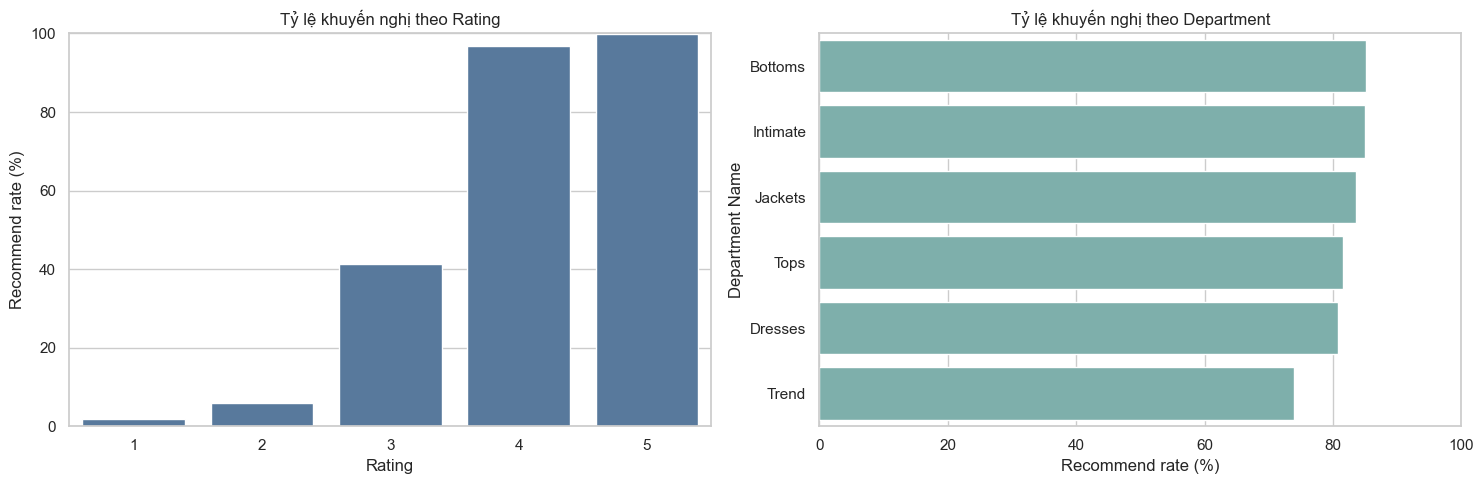

,Rating,count,Recommend rate (%)
0,1,842,1.90
1,2,1565,6.01
2,3,2871,41.41
3,4,5077,96.69
4,5,13131,99.81


,Department Name,count,Recommend rate (%)
0,Bottoms,3799,85.13
1,Intimate,1735,85.01
2,Jackets,1032,83.62
3,Tops,10468,81.52
4,Dresses,6319,80.82
5,Trend,119,73.95


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rating_recommend = df.groupby("Rating")[TARGET_COLUMN].agg(["count", "mean"]).reset_index()
rating_recommend["Recommend rate (%)"] = rating_recommend["mean"] * 100
sns.barplot(data=rating_recommend, x="Rating", y="Recommend rate (%)", color="#4c78a8", ax=axes[0])
axes[0].set(ylim=(0, 100), title="Tỷ lệ khuyến nghị theo Rating")

department_recommend = (
    df.groupby("Department Name")[TARGET_COLUMN]
    .agg(["count", "mean"]).dropna().sort_values("mean", ascending=False).reset_index()
)
department_recommend["Recommend rate (%)"] = department_recommend["mean"] * 100
sns.barplot(data=department_recommend, x="Recommend rate (%)", y="Department Name", color="#76b7b2", ax=axes[1])
axes[1].set(xlim=(0, 100), title="Tỷ lệ khuyến nghị theo Department")
plt.tight_layout()
plt.show()

display(rating_recommend[["Rating", "count", "Recommend rate (%)"]].round(2))
display(department_recommend[["Department Name", "count", "Recommend rate (%)"]].round(2))

Tỷ lệ khuyến nghị tăng rất mạnh theo Rating. Review 1 sao chỉ có 1.90% khuyến nghị, 2 sao là 6.01%, 3 sao là 41.41%, trong khi 4 sao đạt 96.69% và 5 sao gần như luôn khuyến nghị (99.81%).  
Điều này cho thấy Rating có quan hệ cực mạnh với target Recommended IND. Về mặt hành vi, khách hàng đánh giá 4–5 sao hầu như hài lòng và sẵn sàng khuyến nghị; khách hàng đánh giá 1–2 sao hầu như không khuyến nghị.  
Theo Department Name, tỷ lệ khuyến nghị dao động từ 73.95% đến 85.13%. Bottoms và Intimate có tỷ lệ cao nhất, khoảng 85%, trong khi Trend thấp nhất, khoảng 73.95%. Tuy nhiên, Trend chỉ có 119 review nên tỷ lệ này cần được diễn giải thận trọng vì số mẫu nhỏ.  
Điểm cần lưu ý cho bước modeling: nếu dùng Rating để dự đoán Recommended IND, model có thể đạt kết quả rất cao vì hai biến gần như phản ánh cùng một mức độ hài lòng.

### Age, review activity và recommendation

Khảo sát nhóm tuổi, độ dài review và feedback nhằm phát hiện kiểu hành vi: nhóm nào review nhiều hơn, viết dài hơn hoặc có tỷ lệ khuyến nghị khác biệt.

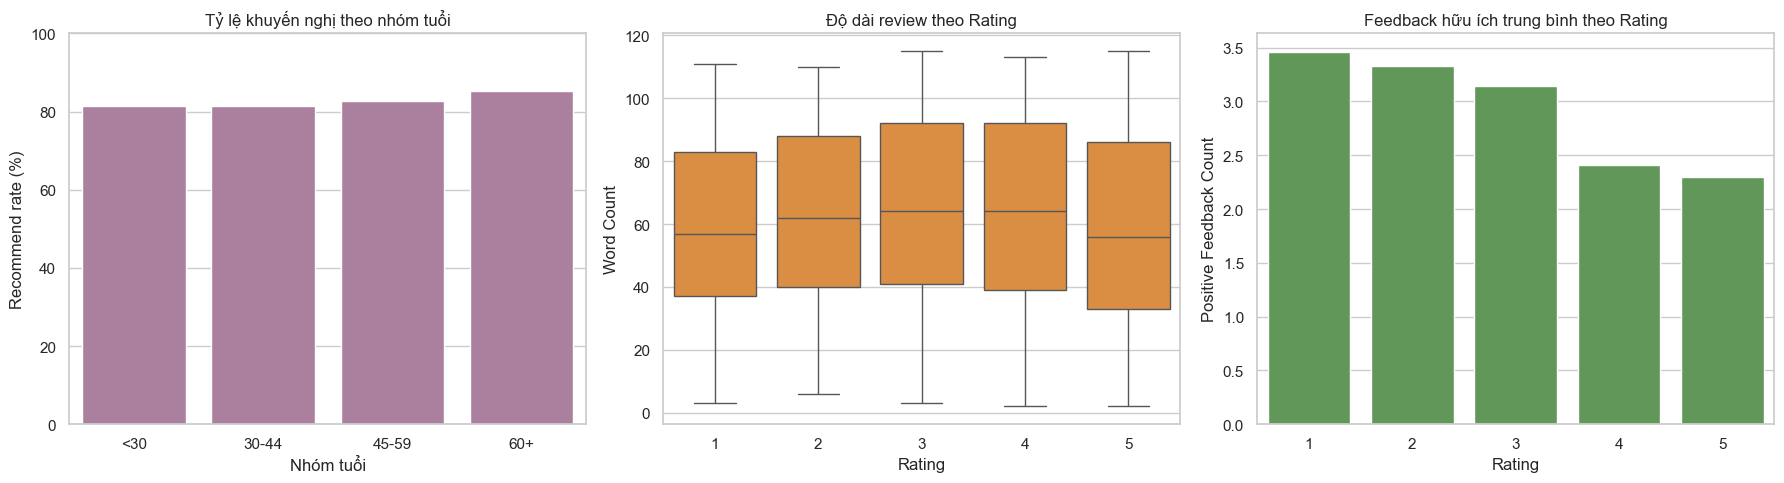

,Age_Group,count,Recommend rate (%)
0,<30,3338,81.43
1,30-44,11029,81.47
2,45-59,6682,82.80
3,60+,2437,85.27


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Tỷ lệ khuyến nghị theo nhóm tuổi
age_group = pd.cut(
    df["Age"],
    bins=[17, 30, 45, 60, 100],
    labels=["<30", "30-44", "45-59", "60+"],
    include_lowest=True
)

age_recommend = (
    df.assign(Age_Group=age_group)
    .groupby("Age_Group", observed=False)[TARGET_COLUMN]
    .agg(["count", "mean"])
    .reset_index()
)

age_recommend["Recommend rate (%)"] = age_recommend["mean"] * 100

sns.barplot(
    data=age_recommend,
    x="Age_Group",
    y="Recommend rate (%)",
    color="#b279a2",
    ax=axes[0]
)
axes[0].set(
    ylim=(0, 100),
    title="Tỷ lệ khuyến nghị theo nhóm tuổi",
    xlabel="Nhóm tuổi"
)

# 2. Độ dài review theo Rating
word_count = df["Review Text"].fillna("").str.split().str.len()

review_for_plot = pd.DataFrame({
    "Rating": df["Rating"],
    "Word Count": word_count
}).query("`Word Count` > 0")

sns.boxplot(
    data=review_for_plot,
    x="Rating",
    y="Word Count",
    color="#f28e2b",
    showfliers=False,
    ax=axes[1]
)
axes[1].set(title="Độ dài review theo Rating")

# 3. Feedback hữu ích trung bình theo Rating
sns.barplot(
    data=df,
    x="Rating",
    y="Positive Feedback Count",
    errorbar=None,
    color="#59a14f",
    ax=axes[2]
)
axes[2].set(
    title="Feedback hữu ích trung bình theo Rating",
    ylabel="Positive Feedback Count"
)

plt.tight_layout()
plt.show()

display(
    age_recommend[
        ["Age_Group", "count", "Recommend rate (%)"]
    ].round(2)
)

Tỷ lệ khuyến nghị khá tương đồng giữa các nhóm tuổi, dao động từ 81.43% đến 85.27%. Nhóm 60+ có tỷ lệ cao nhất (85.27%), nhưng chỉ có 2.437 review; trong khi nhóm 30–44 có nhiều review nhất (11.029) và tỷ lệ khuyến nghị là 81.47%. Vì chênh lệch không lớn, Age có thể chỉ có ảnh hưởng hạn chế đến hành vi khuyến nghị khi xét riêng lẻ.  
Độ dài review không tăng hoặc giảm đều theo Rating. Review 3–4 sao có median số từ cao hơn một chút, còn review 5 sao có median ngắn hơn. Điều này có thể cho thấy khách hàng rất hài lòng thường viết nhận xét ngắn gọn, trong khi các trải nghiệm trung bình hoặc có cả điểm tốt/xấu cần được mô tả chi tiết hơn. Tuy nhiên, các boxplot chồng lấp đáng kể, nên Word Count một mình chưa phân biệt rõ Rating.  
Số lượt feedback hữu ích trung bình giảm dần khi Rating tăng: review 1 sao có trung bình cao nhất, khoảng 3.45 lượt, còn review 5 sao thấp nhất, khoảng 2.3 lượt. Điều này gợi ý các review tiêu cực có thể được người đọc đánh giá là hữu ích hơn, vì chúng thường nêu cụ thể lỗi sản phẩm, kích thước hoặc chất lượng.  
Tuy nhiên, Positive Feedback Count lệch phải và có nhiều outlier, nên giá trị trung bình có thể bị ảnh hưởng bởi một số review cực kỳ phổ biến. Khi phân tích sâu hơn, nên xem thêm median hoặc log-transform feature này.

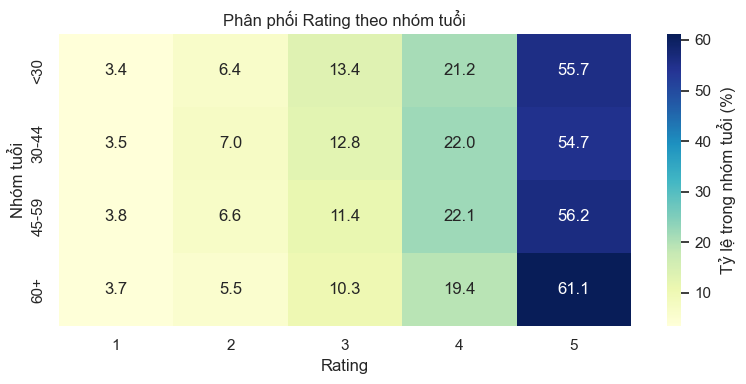

Rating,1,2,3,4,5
Age,,,,,
<30,3.42,6.41,13.36,21.15,55.66
30-44,3.49,7.04,12.80,21.98,54.69
45-59,3.79,6.60,11.40,22.06,56.15
60+,3.69,5.50,10.30,19.41,61.10


In [18]:
age_group = pd.cut(
    df["Age"],
    bins=[17, 30, 45, 60, 100],
    labels=["<30", "30-44", "45-59", "60+"],
    include_lowest=True
)

rating_by_age = pd.crosstab(
    age_group,
    df["Rating"],
    normalize="index"
) * 100

plt.figure(figsize=(8, 4))

sns.heatmap(
    rating_by_age,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Tỷ lệ trong nhóm tuổi (%)"}
)

plt.title("Phân phối Rating theo nhóm tuổi")
plt.xlabel("Rating")
plt.ylabel("Nhóm tuổi")
plt.tight_layout()
plt.show()

display(rating_by_age.round(2))

Từ heatmap phân phối rating theo tuổi, có thể thấy ở tất cả các nhóm tuổi, rating 5 chiếm tỷ lệ lớn nhất. Đặc biệt nhóm 60+ có tới 61.1% đánh giá 5 sao, cao hơn các nhóm còn lại. Ngược lại, tỷ lệ rating 3 và 4 của nhóm 60+ thấp hơn. Điều này củng cố nhận xét rằng nhóm khách hàng lớn tuổi có xu hướng đánh giá tích cực hơn.

### Text behavior và keyword discovery

Review Text được dùng ở mức EDA để đo độ dài và khám phá từ khóa. Các từ thông dụng tiếng Anh được lọc bớt; kết quả không phải phân tích cảm xúc hoàn chỉnh mà là gợi ý về chủ đề khách hàng quan tâm.

### Correlation analysis

Ma trận tương quan chỉ áp dụng cho biến số. Correlation không thể thay thế cho phân tích category hoặc text, nhưng giúp quan sát mối liên hệ tuyến tính giữa Age, Rating, target, feedback và text metrics.

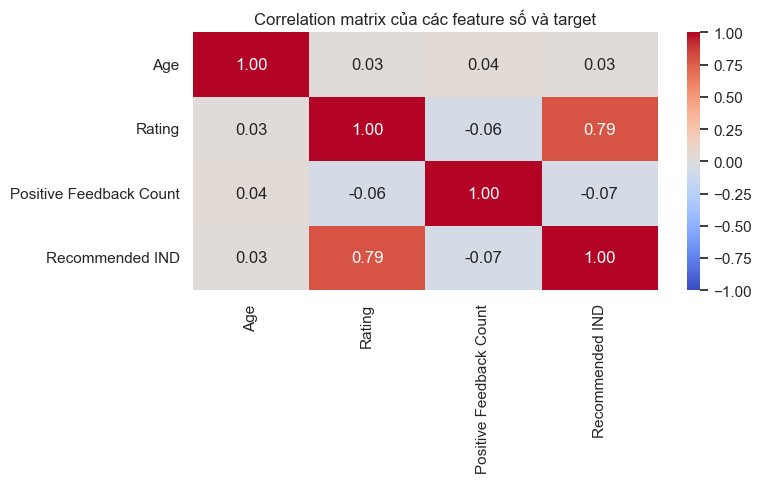

In [24]:
numeric_eda = [
    "Age", "Rating","Positive Feedback Count",TARGET_COLUMN
]
corr = df[numeric_eda].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix của các feature số và target")
plt.tight_layout()
plt.show()


Từ ma trận tương đồng chúng ta thấy rating tương quan mạnh mẽ với recommended IND

## Tổng kết EDA và business interpretation

Sau khi chạy các biểu đồ, phần kết luận cần nêu rõ:
1. Tỷ lệ target theo Recommend IND bị mất cân bằng nặng, có thể cần xử lí để cân bằng nhãn, mô hình sau này cần báo cáo Precision, Recall, F1, ROC-AUC thay vì chỉ Accuracy.
2. Tops có nhiều review nhất (10.468 review, 44.60%), tiếp theo là Dresses (6.319 review, 26.92%) và Bottoms (3.799 review, 16.19%). Ở cấp Class, các loại được review nhiều nhất là Dresses, Knits và Blouses. Về tỷ lệ khuyến nghị, Bottoms cao nhất (85.13%), sau đó là Intimate (85.01%); Trend thấp nhất (73.95%) nhưng chỉ có 119 review nên cần thận trọng khi kết luận. Công ty có thể ưu tiên duy trì trải nghiệm tốt cho Bottoms/Intimate, đồng thời kiểm tra chi tiết review của Trend để tìm nguyên nhân tỷ lệ khuyến nghị thấp hơn.
3. Rating liên hệ rất mạnh với hành vi khuyến nghị: review 4 sao có tỷ lệ khuyến nghị 96.69% và 5 sao là 99.81%, trong khi 1 sao chỉ 1.90% và 2 sao là 6.01%. Nhóm tuổi có khác biệt nhỏ: nhóm 60+ có tỷ lệ khuyến nghị cao nhất (85.27%) và tỷ lệ 5 sao cao nhất (61.1%), nhưng không đủ để kết luận tuổi là nguyên nhân trực tiếp. Độ dài review không có xu hướng rõ rệt theo Rating; review 3–4 sao dài hơn nhẹ, còn 5 sao ngắn hơn, nhưng các phân phối chồng lấp nhiều. Feedback hữu ích trung bình giảm khi Rating tăng: review 1 sao khoảng 3.45 lượt, review 5 sao khoảng 2.3 lượt; điều này gợi ý review tiêu cực thường được người đọc xem là hữu ích hơn.
4. Dataset không có Customer ID, nên mỗi dòng chỉ là một review của một sản phẩm. Vì vậy, kết quả EDA phản ánh hành vi và mức độ hài lòng ở cấp review/sản phẩm, không phải hành vi dài hạn của từng khách hàng. Không thể tính các chỉ số customer-level như số lần mua, thời gian mua gần nhất hoặc tổng chi tiêu; cũng không thể khẳng định một nhóm tuổi hay một khách hàng cụ thể luôn có hành vi như kết quả quan sát.
Ứng dụng kinh doanh sau này: cá nhân hóa gợi ý sản phẩm, phát hiện danh mục có tỷ lệ không khuyến nghị cao để cải thiện sản phẩm, và ưu tiên review có tín hiệu tiêu cực cho bộ phận chăm sóc khách hàng.